# Customer Loyalty & Cohort Analysis
**Datathon 2026 - Retention Deep-Dive**

This notebook investigates the health of our customer base using Cohort Analysis. We aim to determine if the 2018-2019 collapse was due to poor retention of old customers or failure to acquire new ones.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Project configuration
PROCESSED_DIR = Path("../data/processed")
PLOT_DIR = Path("../data/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
pd.options.display.max_columns = None

## 1. Data Loading & Preparation
Identifying the first purchase for each customer.

In [2]:
print("Loading orders...")
orders = pd.read_parquet(PROCESSED_DIR / "orders.parquet")
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Get first purchase date per customer
first_purchase = orders.groupby('customer_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_purchase_date']
first_purchase['cohort'] = first_purchase['first_purchase_date'].dt.to_period('Y').astype(str)

orders = orders.merge(first_purchase[['customer_id', 'cohort']], on='customer_id')
orders['order_year'] = orders['order_date'].dt.year

print("Cohort mapping complete.")

Loading orders...
Cohort mapping complete.


## 2. Cohort Contribution Over Time
How much revenue does each yearly cohort contribute?

In [3]:
order_items = pd.read_parquet(PROCESSED_DIR / "order_items.parquet")
cohort_revenue = orders.merge(order_items, on='order_id')
cohort_revenue['revenue'] = cohort_revenue['quantity'] * cohort_revenue['unit_price']

yearly_revenue = cohort_revenue.groupby(['order_year', 'cohort'])['revenue'].sum().reset_index()

fig = px.bar(yearly_revenue, x='order_year', y='revenue', color='cohort', 
             title='Revenue Contribution by Customer Cohort (First Purchase Year)',
             labels={'order_year': 'Year', 'revenue': 'Total Revenue', 'cohort': 'Cohort (Joined Year)'})

fig.write_image(PLOT_DIR / "15_cohort_revenue_stacked.png")
fig.show()

**Insight:** 
If the '2012-2015' cohort blocks (bottom colors) shrink significantly in 2018-2019, it means we lost our loyal base. If the '2019' block is small compared to previous years, it means acquisition failed.

## 3. Retention Heatmap
Percentage of customers who return after N years.

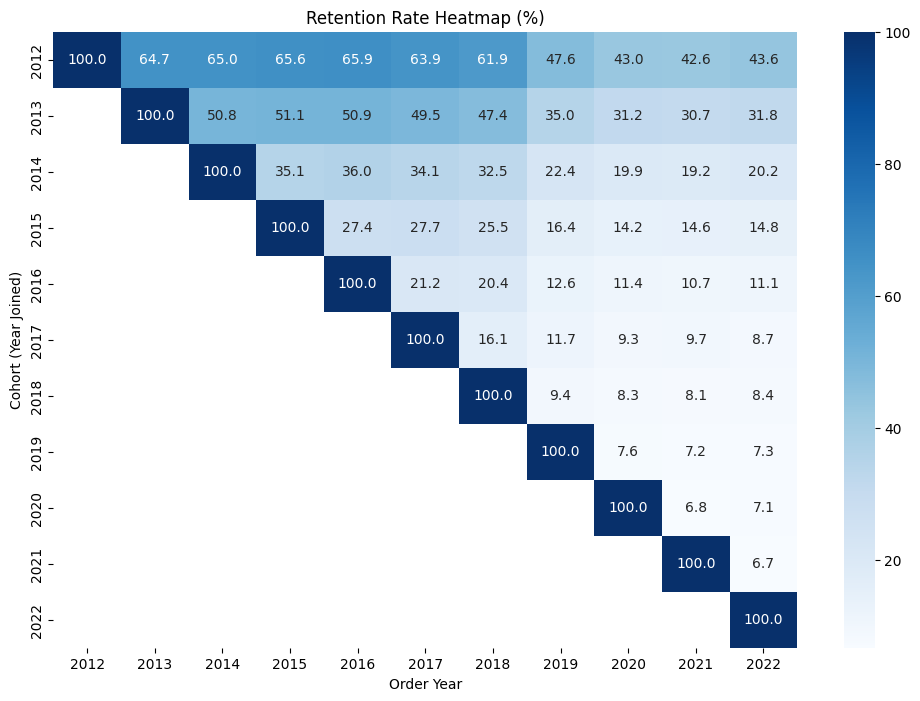

In [4]:
retention = orders.groupby(['cohort', 'order_year'])['customer_id'].nunique().reset_index()
cohort_sizes = first_purchase.groupby('cohort')['customer_id'].nunique().reset_index(name='total_customers')
retention = retention.merge(cohort_sizes, on='cohort')
retention['percentage'] = (retention['customer_id'] / retention['total_customers']) * 100

pivot_retention = retention.pivot(index='cohort', columns='order_year', values='percentage')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_retention, annot=True, fmt='.1f', cmap='Blues')
plt.title('Retention Rate Heatmap (%)')
plt.ylabel('Cohort (Year Joined)')
plt.xlabel('Order Year')
plt.savefig(PLOT_DIR / "16_retention_heatmap.png")
plt.show()

## 4. Average Order Value (AOV) by Cohort
Are older customers spending more over time?

In [5]:
aov_cohort = cohort_revenue.groupby(['order_year', 'cohort'])['revenue'].mean().reset_index()

fig = px.line(aov_cohort, x='order_year', y='revenue', color='cohort', 
              title='Average Order Value (AOV) Trend by Cohort',
              markers=True)
fig.write_image(PLOT_DIR / "17_aov_cohort_trend.png")
fig.show()